# Denoising Diffusion Probabilistic Models (DDPM) on 2D Data

This notebook implements a minimal denoising diffusion probabilistic model (DDPM) and trains it on small 2D datasets (e.g., a T-rex shape, moons). The goal is to illustrate how diffusion models frame data generation as an iterative denoising optimization problem, connecting the forward noising process, the reverse denoising process, and the noise-prediction training objective.

**Learning objectives:**

- Understand the forward diffusion process $q(x_t \mid x_{t-1})$ and how it gradually destroys data structure.
- Derive and implement the simplified training loss $\mathcal{L} = \mathbb{E}_{t,x_0,\epsilon}\|\epsilon - \epsilon_\theta(x_t, t)\|^2$.
- Observe how the noise schedule $\beta_t$, input embeddings, and time embeddings affect sample quality.
- Visualize the reverse (generative) process that recovers data from pure noise.

## Setup

**Requirements:** `torch`, `torchvision`, `matplotlib`, `scikit-learn`, `pandas`, `scipy`. Install them with `pip install torch torchvision matplotlib scikit-learn pandas scipy` if needed.

In [ ]:
# Imports
import torch
import torchvision
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import gzip
import math
import os
import time
import shutil

from sklearn.datasets import make_moons
from torch.utils.data import TensorDataset

# Check and print the device being used by PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Background: Diffusion Models as Optimization

Diffusion models learn to generate data by reversing a gradual noising process. The key idea has two parts.

**Forward process.** Given a data point $x_0$, we define a Markov chain that adds Gaussian noise over $T$ steps:

$$
q(x_t \mid x_{t-1}) = \mathcal{N}\!\bigl(x_t;\, \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t I\bigr),
$$

where $\beta_1, \ldots, \beta_T$ is a predetermined *noise schedule* with $0 < \beta_t < 1$. Setting $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$, we can sample $x_t$ directly from $x_0$:

$$
x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I).
$$

As $t$ grows, $\bar{\alpha}_t \to 0$ and $x_t$ converges to an isotropic Gaussian.

**Reverse process and training objective.** A neural network $\epsilon_\theta(x_t, t)$ is trained to predict the noise $\epsilon$ that was added. The simplified variational (ELBO) loss reduces to:

$$
\mathcal{L} = \mathbb{E}_{t,\, x_0,\, \epsilon}\bigl[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\bigr].
$$

At generation time we start from $x_T \sim \mathcal{N}(0,I)$ and iteratively denoise to obtain a sample $x_0$.

This notebook is adapted from [andrewkchan's Diffusion Models blog post](https://andrewkchan.dev/posts/diffusion.html) and [tanelp's tiny-diffusion](https://github.com/tanelp/tiny-diffusion). We train on small 2D datasets so everything runs on CPU.

### Generate/Load dataset
First let's load our T-rex dataset and sanity check that it looks right. The `DatasaurusDozen.tsv` file is automatically downloaded from GitHub if it is not already present in the working directory.


In [ ]:
import urllib.request
import os

data_path = 'DatasaurusDozen.tsv'
if not os.path.exists(data_path):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/jumpingrivers/datasauRus/main/inst/extdata/DatasaurusDozen.tsv',
        data_path
    )


def moons_dataset(n=8000):
    X, _ = make_moons(n_samples=n, random_state=42, noise=0.03)
    X[:, 0] = (X[:, 0] + 0.3) * 2 - 1
    X[:, 1] = (X[:, 1] + 0.3) * 3 - 1
    return TensorDataset(torch.from_numpy(X.astype(np.float32)))


def line_dataset(n=8000):
    rng = np.random.default_rng(42)
    x = rng.uniform(-0.5, 0.5, n)
    y = rng.uniform(-1, 1, n)
    X = np.stack((x, y), axis=1)
    X *= 4
    return TensorDataset(torch.from_numpy(X.astype(np.float32)))


def circle_dataset(n=8000):
    rng = np.random.default_rng(42)
    x = np.round(rng.uniform(-0.5, 0.5, n)/2, 1)*2
    y = np.round(rng.uniform(-0.5, 0.5, n)/2, 1)*2
    norm = np.sqrt(x**2 + y**2) + 1e-10
    x /= norm
    y /= norm
    theta = 2 * np.pi * rng.uniform(0, 1, n)
    r = rng.uniform(0, 0.03, n)
    x += r * np.cos(theta)
    y += r * np.sin(theta)
    X = np.stack((x, y), axis=1)
    X *= 3
    return TensorDataset(torch.from_numpy(X.astype(np.float32)))


def dino_dataset(n=8000):
    df = pd.read_csv(data_path, sep="\t")
    df = df[df["dataset"] == "dino"]
    X = np.asarray(df[['x','y']].values, dtype=float).reshape(-1,2)
    return TensorDataset(torch.from_numpy(X.astype(np.float32)))


def get_dataset(name, n=8000):
    if name == "moons":
        return moons_dataset(n)
    elif name == "dino":
        return dino_dataset(n)
    elif name == "line":
        return line_dataset(n)
    elif name == "circle":
        return circle_dataset(n)
    else:
        raise ValueError(f"Unknown dataset: {name}")

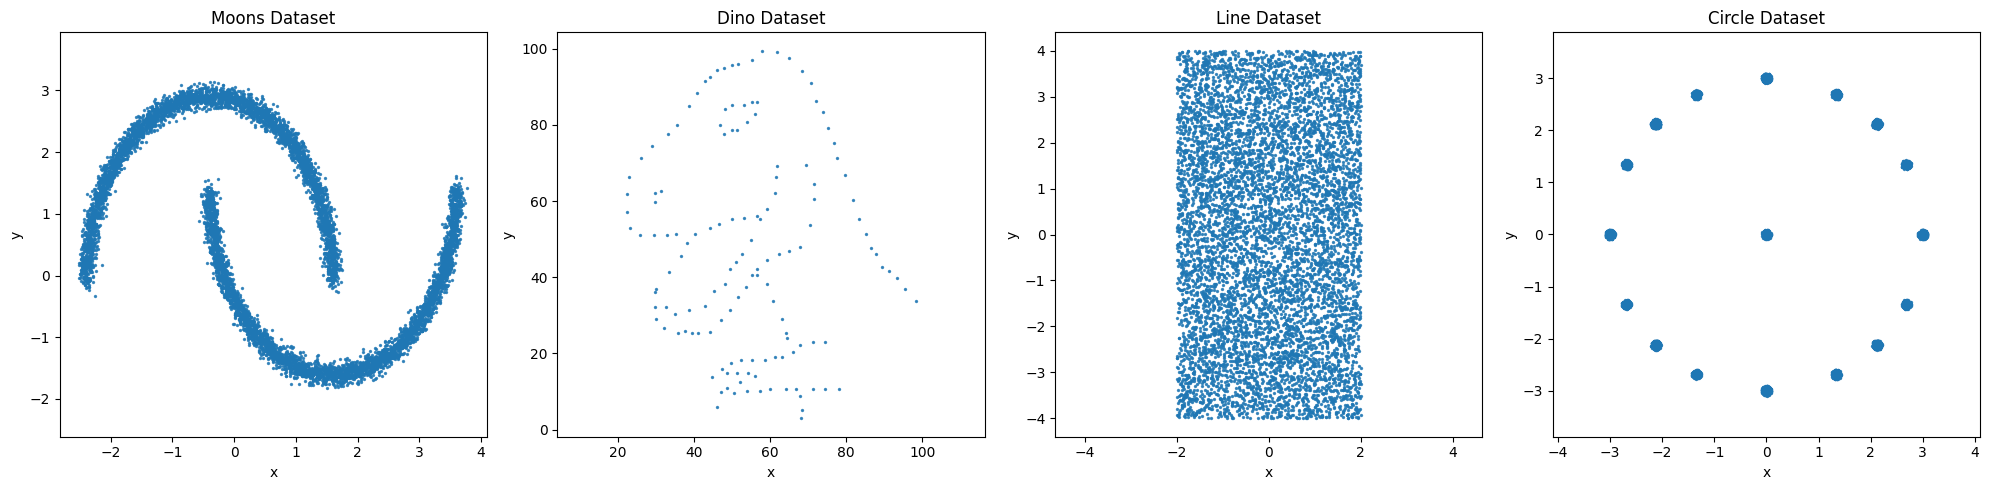

In [84]:
dataset_names = ["moons", "dino", "line", "circle"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 4 columns

for i, name in enumerate(dataset_names):
    dataset = get_dataset(name)
    X, = dataset[:]
    X = X.numpy()

    # Plot each dataset in a separate subplot
    axes[i].scatter(X[:, 0], X[:, 1], s=2, alpha=0.8)
    axes[i].set_title(f'{name.capitalize()} Dataset')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

## Visualize the Forward Noising Process

Before training a model, let us visualize what happens as we add noise. We use a **linear noise schedule** with $\beta_{\min} = 10^{-4}$ and $\beta_{\max} = 0.02$ over $T = 200$ steps. Equivalently, $\alpha_t = 1 - \beta_t$ decreases linearly from $\alpha_{\max} = 0.9999$ to $\alpha_{\min} = 0.98$.

The cumulative product $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$ controls the signal-to-noise ratio at step $t$:
- When $\bar{\alpha}_t \approx 1$ (early steps), most of the original signal is retained.
- When $\bar{\alpha}_t \approx 0$ (late steps), the data is nearly pure Gaussian noise.

The plots below show $\alpha_t$ and $\bar{\alpha}_t$ as functions of the timestep.

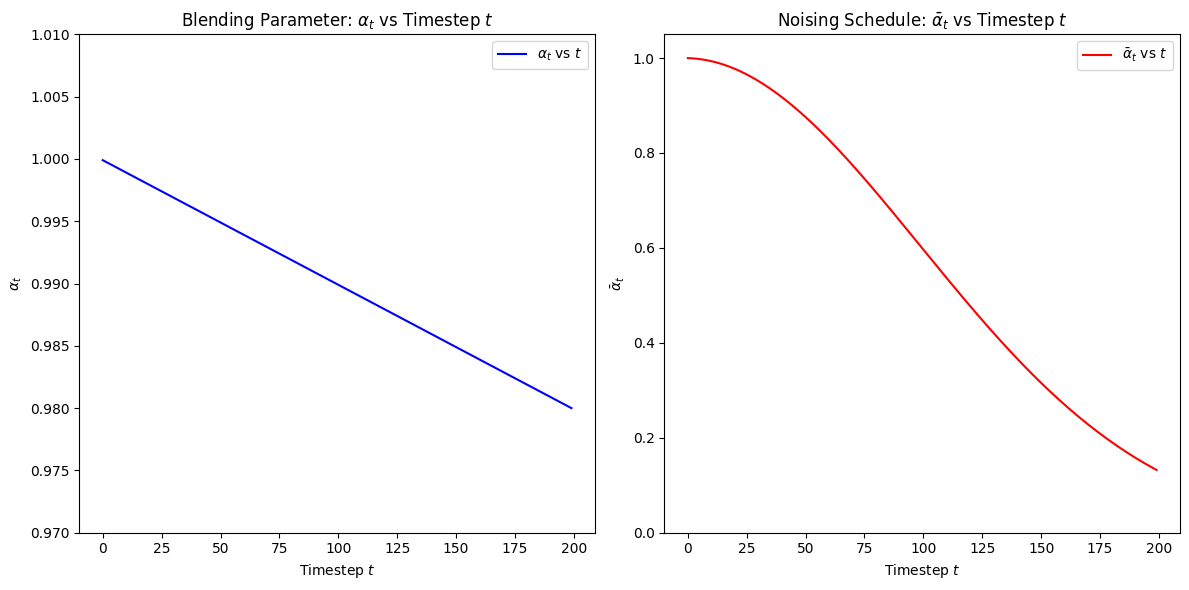

In [55]:

# Define parameters
alpha_min = 0.98
alpha_max = 0.9999
T = 200

# Calculate alpha and alpha_bar
alpha = torch.linspace(alpha_max, alpha_min, T)
alpha_bar = torch.cumprod(alpha, dim=-1).reshape(-1, 1)

# Set up the figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot alpha_t vs Timestep t
axes[0].plot(torch.arange(T), alpha, label=r'$\alpha_t$ vs $t$', color='b')
axes[0].set_xlabel('Timestep $t$')
axes[0].set_ylabel(r'$\alpha_t$')
axes[0].set_title(r'Blending Parameter: $\alpha_t$ vs Timestep $t$')
axes[0].legend()
axes[0].set_ylim(0.97, 1.01)  # To keep focus on small variation in alpha

# Plot alpha_bar_t vs Timestep t
axes[1].plot(torch.arange(T), alpha_bar, label=r'$\bar{\alpha}_t$ vs $t$', color='r')
axes[1].set_xlabel('Timestep $t$')
axes[1].set_ylabel(r'$\bar{\alpha}_t$')
axes[1].set_title(r'Noising Schedule: $\bar{\alpha}_t$ vs Timestep $t$')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Define the forward process



The forward process in the context of a diffusion model involves gradually adding noise to the data over multiple time steps. This process transforms an initially structured data distribution into a noise distribution by incrementally applying Gaussian noise with a carefully selected variance schedule. The noising schedule, defined by $\beta_t$, governs how the variance evolves over time. At each timestep $t$, the noisy data is a blend of the previous data and added Gaussian noise, controlled by cumulative product terms $\alpha_t$ and $\bar{\alpha}_t$.

Mathematically, the forward process can be described as:

\begin{align}
\mathbf{x}_t = \sqrt{\bar{\alpha}_t} \cdot \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \mathbf{z}
\end{align}

where $\mathbf{x}_0$ is the original data, $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ represents the Gaussian noise, and $\bar{\alpha}_t$ is defined as:

\begin{align}
\bar{\alpha}_t = \prod_{s=1}^t \alpha_s, \quad \text{with} \quad \alpha_t = 1 - \beta_t
\end{align}

This forward process enables a continuous transformation that prepares the data for later steps in generative models such as denoising diffusion probabilistic models.



1. **Variance Schedule**:
   - The `beta` values represent the noise variance at each time step. Here, `torch.linspace(beta_min, beta_max, n_steps)` creates a linearly increasing schedule from `beta_min` to `beta_max`.

2. **Alpha and Alpha Bar**:
   - `alpha = 1. - beta` represents how much of the original data is retained after each noise addition step.
   - `alpha_bar = torch.cumprod(alpha, dim=0)` computes the cumulative product of $\alpha_t$, which is used to compute how much of the original signal remains after $t$ timesteps.

3. **Noise Addition Loop**:
   - **Initialization**:
     - The process starts with the original dataset (`s = dataset`) and stores it in the `series` list.
   - **Loop for Adding Noise**:
     - At each timestep \(t\), Gaussian noise (`torch.randn_like(dataset)`) is generated.
     - The noisy data for the current timestep is computed using the formula:
       $$
       \text{noisy\_data} = \text{series}[-1] \cdot \sqrt{\bar{\alpha}_t} + \sqrt{1 - \bar{\alpha}_t} \cdot \text{noise}
      $$

     - The result is appended to the `series` list, allowing the noise accumulation to progress through all \(n\) steps.

4. **Return**:
   - The function returns the `series`, which contains all versions of the dataset, starting from the original up to the noisiest one.
 he process and generate structured samples from random noise.

In [56]:
import torch

def forward_noise_dataset(dataset, n_steps=1000, beta_min=0.0001, beta_max=0.02):
    """
    Applies the forward noising process to a given dataset.

    Parameters:
    - dataset: The original data to which noise will be applied.
    - n_steps: The number of steps in the forward noising process.
    - beta_min: The minimum value of beta for the noise variance schedule.
    - beta_max: The maximum value of beta for the noise variance schedule.

    Returns:
    - series: A list of datasets representing the noisy data at each time step.
    """
    # Variance schedule (beta) linearly increasing from beta_min to beta_max over n_steps.
    beta = torch.linspace(beta_min, beta_max, n_steps)

    # Compute alpha and cumulative product alpha_bar.
    alpha = 1. - beta
    alpha_bar = torch.cumprod(alpha, dim=0)

    # Initialize the series with the original dataset.
    s = dataset
    series = [s]

    # Iteratively apply noise at each time step.
    for t in range(n_steps):
        # Generate Gaussian noise with the same shape as the dataset.
        noise = torch.randn_like(dataset)

        # Compute the noisy dataset for the current timestep t.
        noisy_data = series[-1] * alpha_bar[t].sqrt() + (1. - alpha_bar[t]).sqrt() * noise

        # Append the new noisy dataset to the series.
        series.append(noisy_data)

    return series


def scatters(cols, rows, datasets, labels, timesteps, width=14):
    """
    Create scatter plots for given datasets in a grid format.

    Parameters:
    - cols: Number of columns in the grid.
    - rows: Number of rows in the grid.
    - datasets: List of datasets to plot.
    - labels: List of labels for each plot.
    - timesteps: List of timesteps to include in the title.
    - width: Width of the figure.
    """
    figure = plt.figure(figsize=(width, rows / cols * width))
    for i in range(cols * rows):
        dataset, label, t = datasets[i], labels[i], timesteps[i]
        ax = figure.add_subplot(rows, cols, i + 1)
        plt.title(f't = {t}')
        plt.axis("off")
        ax.scatter(dataset[:, 0], dataset[:, 1], s=15, alpha=0.5)
    plt.show()


## Plot the forward process of the T-rex dataset

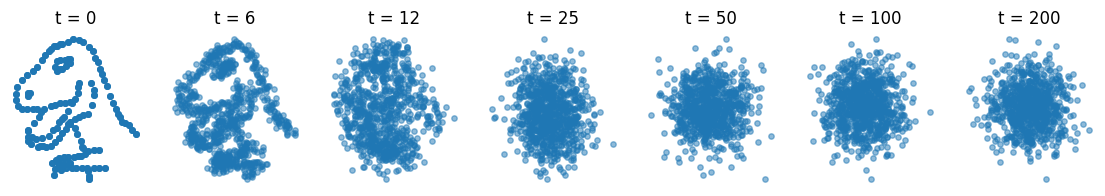

In [59]:


datasaurus_dataset = get_dataset('dino')
datasaurus_tensor, = datasaurus_dataset[:]

datasaurus_tensor = (datasaurus_tensor - datasaurus_tensor.mean())/datasaurus_tensor.std()
trex_viz_input = torch.cat(
    (datasaurus_tensor, datasaurus_tensor, datasaurus_tensor, datasaurus_tensor, datasaurus_tensor, datasaurus_tensor),
    dim=0
)


datasaurus_series = forward_noise_dataset(trex_viz_input, beta_min=(1-0.9999), beta_max=(1-0.95), n_steps=200)

for i in range(len(datasaurus_series)):
    data = datasaurus_series[i]
    plt.figure(figsize=[6, 6])
    plt.scatter(data[:,0], data[:,1],s=15,alpha=0.5)
    plt.axis('off')
    plt.close()

display_ts = [0, 6, 12, 25, 50, 100, 200]

scatters(len(display_ts), 1, [datasaurus_series[i] for i in display_ts], ["" for _ in range(len(display_ts))], display_ts)


### Checking Convergence to a Gaussian Distribution

After $T$ steps of the forward process, the noisy data $x_T$ should be approximately standard Gaussian. We verify this with a **Kolmogorov--Smirnov test**, which measures the maximum discrepancy between the empirical CDF of $x_T$ and the standard normal CDF. A large $p$-value (e.g., $> 0.05$) means we cannot reject the null hypothesis that the data came from $\mathcal{N}(0,1)$.

In [60]:
from scipy import stats

# Check if the last element in datasaurus_series is close to a standard Gaussian
last_element = datasaurus_series[-1].numpy()

# Flatten the data to use in the KS test
flattened_data = last_element.flatten()

# Perform Kolmogorov-Smirnov test to compare with standard Gaussian
ks_stat, p_value = stats.kstest(flattened_data, 'norm')

# Print results
if p_value > 0.05:
    print(f"The KS test p-value is {p_value:.4f}. The distribution is not significantly different from a standard Gaussian (fail to reject null hypothesis).")
else:
    print(f"The KS test p-value is {p_value:.4f}. The distribution is significantly different from a standard Gaussian (reject null hypothesis).")

The KS test p-value is 0.7140. The distribution is not significantly different from a standard Gaussian (fail to reject null hypothesis).


### Visualize reverse process

For fun, we can visualize the estimated "drift vector" fields, e.g. the expected direction that a noisy point came from in the previous timestep. This is what our denoising model will learn.

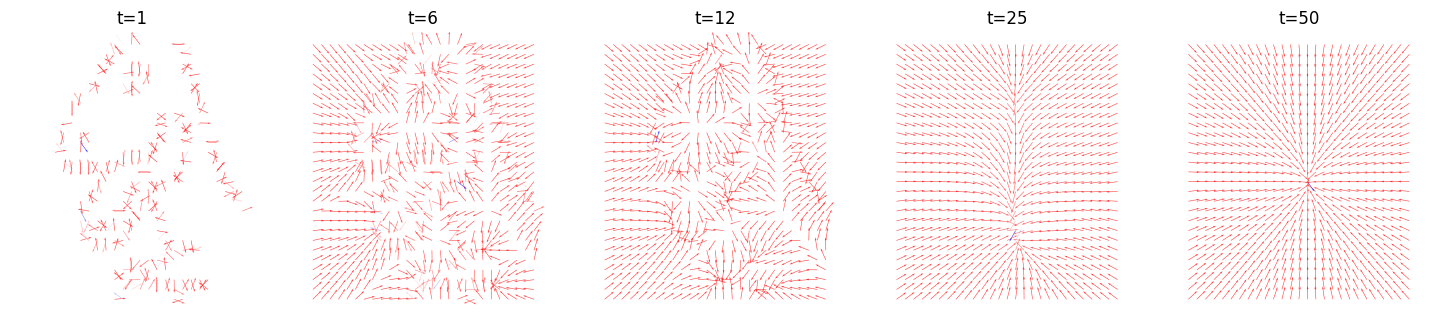

In [61]:
# Function to compute drift grids for visualizing the forward diffusion process
def drift_grids(dataset, xrange=(-2, 2, 0.15), yrange=(-2, 2, 0.15), n_steps=1000, beta_min=0.0001, beta_max=0.02):
    # Create a grid of points using meshgrid based on the given range
    X, Y = np.meshgrid(np.arange(*xrange), np.arange(*yrange))
    XY = torch.tensor(np.stack((X, Y), axis=-1))  # Stack X and Y to create a tensor representing all grid points

    # Variance schedule linearly increasing from beta_min to beta_max over n_steps
    beta = torch.linspace(beta_min, beta_max, n_steps)
    alpha = 1. - beta
    alpha_bar = torch.cumprod(alpha, dim=0)  # Cumulative product of alpha to compute alpha_bar

    # Create a version of the dataset replicated across the grid
    dataset_grid = torch.tensor(np.full(XY.shape[:-1] + dataset.shape, dataset))

    # Initialize drift with zeros
    s = torch.zeros_like(XY)
    series = [s]  # List to store drift vectors for each timestep

    # Loop through each timestep to compute drift
    for t in range(n_steps):
        # Get alpha_bar at the previous timestep (initialize with 1.0 for the first step)
        alpha_bar_t1 = alpha_bar[t - 1] if t > 0 else torch.tensor(1.0)

        # Expand grid points for broadcasting in calculations
        xts = XY[:, :, None, :]  # [xlen, ylen, 1, 2]
        x0s = dataset_grid  # [xlen, ylen, N, 2]

        # Compute the expected value (mu) at timestep t
        mus = (alpha[t].sqrt() * (1 - alpha_bar_t1) * xts + alpha_bar_t1.sqrt() * (1 - alpha[t]) * x0s) / (1 - alpha_bar[t])

        # Compute weights for each dataset point based on its proximity to the current grid point
        weights = torch.exp(-torch.linalg.vector_norm(xts - alpha_bar[t].sqrt() * x0s, ord=2, dim=-1) / (1 - alpha_bar[t]) / 2)

        # Normalize weights to sum to 1
        weights = weights / torch.sum(weights, dim=2, keepdim=True)

        # Compute weighted average to get drift direction (mu)
        mus = torch.sum(mus * weights[..., None], dim=2)  # [xlen, ylen, 2]

        # Compute drift as the difference between expected value (mu) and the current position (xts)
        drift = mus - xts.reshape(mus.shape)  # [xlen, ylen, 2]

        # Normalize the drift to improve visualization (avoid excessively large vectors)
        magnitude = torch.linalg.vector_norm(drift, ord=2, dim=-1, keepdim=True)
        drift = drift / (magnitude + 1e-5)  # Add a small epsilon to prevent division by zero
        drift *= 0.1  # Scale the drift vector to control arrow length for visualization

        # Append the computed drift for the current timestep to the series list
        series.append(drift.numpy())

    return series

# Function to create quiver plots for visualizing vector fields
def quivers(cols, rows, datasets, labels, width=14, xrange=(-2, 2, 0.15), yrange=(-2, 2, 0.15)):
    # Create meshgrid for plotting vectors on the grid
    X, Y = np.meshgrid(np.arange(*xrange), np.arange(*yrange))
    figure = plt.figure(figsize=(1.3* width, 1.3* rows / cols * width))  # Set the figure size

    # Loop through the number of datasets to create a quiver plot for each one
    for i in range(cols * rows):
        dataset, label = datasets[i], labels[i]
        ax = figure.add_subplot(rows, cols, i + 1)  # Add subplot for each dataset
        plt.title(label)
        plt.axis("off")

        # Calculate magnitude of drift vectors for coloring the arrows
        magnitude = np.linalg.norm(dataset, axis=-1)
        color = magnitude  # Use magnitude as color to visualize drift intensity

        # Plot the quiver using X, Y grid points, and the components of the drift vectors
        ax.quiver(X, Y, dataset[:, :, 0], dataset[:, :, 1], color, angles='xy', scale_units='xy', scale=0.5, cmap='bwr', alpha=0.75)

    # Show the figure
    plt.show()


# Parameters for the drift computation and quiver plotting
xrange = (-2, 2, 0.15)
yrange = (-2, 2, 0.15)

# Compute the drift grids for datasaurus_tensor using forward diffusion
datasaurus_drift = drift_grids(datasaurus_tensor, beta_min=(1 - 0.9999), beta_max=(1 - 0.95), n_steps=50, xrange=xrange, yrange=yrange)

# Define timesteps to visualize
display_ts = [1, 6, 12, 25, 50]

# Visualize selected timesteps of the drift using quiver plots
quivers(len(display_ts), 1, [datasaurus_drift[i] for i in display_ts], [f"t={t}" for t in display_ts], xrange=xrange, yrange=yrange)


## Reverse Process and Training Loss

### Forward Process (Recap)

The forward process adds noise over $T$ timesteps via:

$$
x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I).
$$

### Reverse Process

The **reverse process** starts from $x_T \sim \mathcal{N}(0, I)$ and iteratively removes noise. At each step a neural network $\epsilon_\theta(x_t, t)$ predicts the noise that was added. The predicted mean of $x_{t-1}$ given $x_t$ is:

$$
\widehat{\mu}_t = \frac{1}{\sqrt{\alpha_t}}\Bigl(x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}}\,\epsilon_\theta(x_t, t)\Bigr).
$$

Sampling then proceeds as $x_{t-1} = \widehat{\mu}_t + \sigma_t z$, where $z \sim \mathcal{N}(0, I)$ and $\sigma_t = \sqrt{1 - \alpha_t}$.

### Training Objective

The simplified ELBO loss trains $\epsilon_\theta$ to predict the noise:

$$
\mathcal{L} = \mathbb{E}_{t,\, x_0,\, \epsilon}\bigl[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\bigr].
$$

This is a standard mean-squared-error (MSE) regression problem: for a random timestep $t$ and random noise $\epsilon$, construct $x_t$ from $x_0$, then minimize the $\ell_2$-distance between the true noise $\epsilon$ and the network's prediction.

In [62]:
import torch

@torch.no_grad()  # Disable gradient calculation to save memory and computations since we're sampling (inference)
def sample(num_samples, model, alpha_min=0.94, alpha_max=0.999, T=200, device='cpu'):
    # Define the variance schedule (alpha), linearly decreasing from alpha_max to alpha_min over T timesteps
    alpha = torch.linspace(alpha_max, alpha_min, T).to(device)

    # Compute cumulative product of alpha to get alpha_bar for all timesteps
    alpha_bar = torch.cumprod(alpha, dim=-1).reshape(-1, 1)

    # Initialize a list to store intermediate samples at each step
    steps = []

    # Start with random Gaussian noise (xt) with shape [num_samples, 2]
    xt = torch.randn((num_samples, 2)).to(device)

    # Reverse diffusion process: iterate over all timesteps from T-1 to 0
    for t in reversed(range(T)):
        # Create a batch of timesteps `t`, with shape [num_samples]
        t_batch = torch.full((num_samples,), t).to(device)

        # Use the model to predict the noise component for current noisy sample xt and timestep t
        noise_pred = model(xt, t_batch)

        # Calculate mu_hat_t, which represents the predicted clean sample at timestep t
        # This is derived from the reverse process equation
        mu_hat_t = (xt - (1 - alpha[t]) / (1 - alpha_bar[t]).sqrt() * noise_pred) / (alpha[t]).sqrt()

        # Generate Gaussian noise with the same shape as xt
        z = torch.randn_like(xt).to(device)

        # Define the standard deviation for the reverse step noise
        sigma = (1. - alpha[t]).sqrt()

        # Update xt to simulate the reverse diffusion step, adding stochasticity with sigma * z
        xt = mu_hat_t + sigma * z

        # Append the intermediate result to steps (make a copy and move to CPU for storage)
        steps.append(xt.clone().detach().to('cpu'))

    # Return the list of intermediate steps; contains samples at each step of the reverse diffusion
    return steps


## Training the Model
The training function aims to train a **neural network model** to predict the noise component added during the forward process.

- **Forward Pass**:
  - The original data `x0` is taken from the `train_dataloader`.
  - Noise `eps` is added to `x0` at a random timestep `t` using the formula:

  $$
  \mathbf{x}_t = \sqrt{\bar{\alpha}_t} \cdot \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon
  $$

  - $\mathbf{x}_t$ is then fed into the model, which is tasked to predict the noise `eps`.

- **Loss Function**:
  - The loss function used is the **Mean Squared Error (MSE)** between the **predicted noise** (`eps_pred`) and the **actual noise** (`eps`) that was used in the forward process:

$$
  \text{loss} = \text{MSE}(\epsilon_{\text{pred}}, \epsilon)
$$

  - The MSE loss encourages the model to correctly predict the noise added to the data, effectively learning how to "denoise" it.

- **Optimization**:
  - The loss is used to perform backpropagation, calculate gradients, and update the model parameters.
  - **Gradient Clipping** (`torch.nn.utils.clip_grad_norm_`) is applied to prevent gradient explosion, ensuring that the model trains stably.

- **Testing**:
  - After every epoch, the model is evaluated on the `test_dataloader` using the same loss function.
  - The loss over the test dataset is **exponentially smoothed** before storing it. This helps stabilize the loss curve and reduce noise.

- **Plotting the Loss**:
  - The losses collected over each epoch are plotted at the end to visualize the training process.

In [69]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

import torch
import matplotlib.pyplot as plt
import numpy as np

def train(model, train_dataloader, test_dataloader, alpha_min=0.94, alpha_max=0.999, T=200, n_epochs=50, lr=4e-3, device='cpu'):
    # Set up the optimizer with Adam algorithm and specified learning rate
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # Define the variance schedule alpha, linearly decreasing from alpha_max to alpha_min over T timesteps
    alpha = torch.linspace(alpha_max, alpha_min, T, device=device)
    # Compute cumulative product of alpha to get alpha_bar for all timesteps
    alpha_bar = torch.cumprod(alpha, dim=-1).reshape(-1, 1)

    # Lists to store the training and test losses
    training_losses = []
    test_losses = []

    # Start training loop over epochs
    for e in range(n_epochs):
        model.train()  # Set model to training mode

        # Track cumulative loss for this epoch to calculate average training loss
        epoch_train_loss = 0
        num_train_batches = 0

        # Loop through the training data
        for x0s in train_dataloader:
            x0s = x0s[0]  # Extract the data (first element)
            eps = torch.randn_like(x0s)  # Generate Gaussian noise with the same shape as x0s

            # Randomly choose a timestep t for each sample in the batch
            t = torch.randint(T, (x0s.shape[0],), device=device)

            # Compute noisy version of x0s at timestep t (forward process)
            xts = alpha_bar[t].sqrt() * x0s + (1. - alpha_bar[t]).sqrt() * eps

            # Predict noise from the noisy samples xts
            eps_pred = model(xts, t)

            # Compute mean squared error (MSE) loss between predicted noise and true noise
            loss = torch.nn.functional.mse_loss(eps_pred, eps)

            # Backpropagation: calculate gradients
            loss.backward()

            # Clip gradients to prevent explosion
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update model parameters using the optimizer
            opt.step()

            # Set gradients to zero before the next step
            opt.zero_grad()

            # Accumulate training loss and count the number of training batches
            epoch_train_loss += loss.item()
            num_train_batches += 1

        # Calculate average training loss for this epoch
        avg_train_loss = epoch_train_loss / num_train_batches
        training_losses.append(avg_train_loss)

        # Evaluate the model on the test dataset after each epoch
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():
            test_batch_losses = []  # List to store losses for each batch
            test_batch_sizes = []  # List to store batch sizes

            # Loop through the test data
            for x0s in test_dataloader:
                x0s = x0s[0]
                eps = torch.randn_like(x0s)  # Generate Gaussian noise

                # Randomly choose a timestep t for each sample in the batch
                t = torch.randint(T, (x0s.shape[0],), device=device)

                # Compute noisy version of x0s at timestep t
                xts = alpha_bar[t].sqrt() * x0s + (1. - alpha_bar[t]).sqrt() * eps

                # Predict noise from the noisy samples xts
                eps_pred = model(xts, t)

                # Compute loss and store it for each batch
                loss = torch.nn.functional.mse_loss(eps_pred, eps)
                test_batch_losses.append(loss.item() * x0s.shape[0])  # Multiply loss by batch size
                test_batch_sizes.append(x0s.shape[0])

            # Calculate average loss for the test dataset
            avg_test_loss = sum(test_batch_losses) / sum(test_batch_sizes)
            test_losses.append(avg_test_loss)

    # Plot the training and test losses over epochs
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))  # Create a figure with 1 row and 2 columns

    # Plot training loss
    ax[0].plot(np.arange(n_epochs), training_losses, label='Training Loss', color='blue')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Training Loss Curve')
    ax[0].legend()

    # Plot test loss
    ax[1].plot(np.arange(n_epochs), test_losses, label='Test Loss', color='red')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].set_title('Test Loss Curve')
    ax[1].legend()

    # Show the plots
    plt.tight_layout()
    plt.show()

## Define the Model --- a Noise-Predicting Neural Network



`DenoisingMLP` is designed to learn to predict the noise during the reverse process of a **diffusion model**. This model is an instance of a **multilayer perceptron (MLP)**, and it utilizes different types of **embeddings** for both the input data (`xt`) and the time step (`t`). Let's break down the components and the purpose of each part of the code.


The model is parameterized by several options:
- **Input Embedding (`input_embedding`)**: Can be `fourier` or `identity`, which determines how the input (`xt`) is encoded before being processed by the network.
- **Time Embedding (`time_embedding`)**: Can be `fourier`, `linear`, or `zero`, which determines how the time step (`t`) is encoded.



##### Input Embedding
```python
if input_embedding == 'fourier':
    self.input_L = 64
    self.input_B = torch.randn((self.input_L // 2, 2)).to(device)
elif input_embedding == 'identity':
    self.input_L = 2
else:
    raise Exception("unknown input embedding")
```
- **Fourier Embedding**:
  - Uses random projections to encode the input into a higher-dimensional space.
  - `self.input_B` is a matrix of random values with dimensions `(self.input_L // 2, 2)` where `input_L` is set to `64`. This matrix will be used to compute Fourier features.
  - Fourier embeddings are used because they help in capturing **periodic patterns** in data.
- **Identity Embedding**:
  - No transformation is applied to the input (`input_L = 2`).
  - It means the input (`xt`) is directly passed to the network.


##### During Forward Pass:
```python
if self.input_embedding == 'fourier':
    xt = (self.input_B @ xt.T).T
    xt = torch.cat((torch.sin(xt), torch.cos(xt)), dim=1)
```
- **Fourier Embedding for Input (`xt`)**:
  - The input `xt` is projected using `self.input_B`, which creates sinusoidal features to encode periodic properties.
  - The embedding consists of both **sine** and **cosine** components of the projections, which are concatenated along the feature dimension.





##### Time Embedding
```python
self.time_embedding = time_embedding
if time_embedding == 'fourier':
    self.time_L = 32
    self.time_B = torch.randn((self.time_L // 2, 1)).to(device)
elif time_embedding == 'linear':
    self.time_L = 1
elif time_embedding == 'zero':
    self.time_L = 0
else:
    raise Exception("unknown time embedding")
```
- **Fourier Embedding**:
  - Similar to the input, the time step (`t`) is embedded using Fourier features.
  - `self.time_B` is a random matrix of size `(self.time_L // 2, 1)`, where `time_L` is set to `32`.
- **Linear Embedding**:
  - Encodes time step `t` linearly. The resulting embedding is of size 1.
- **Zero Embedding**:
  - No time information is included (`time_L = 0`). This implies the model is not explicitly given any information about the time step.

##### During Forward Pass:
```python
if self.time_embedding == 'fourier':
    t = t / self.T - 0.5
    t = (self.time_B @ t[..., None].T).T
    t = torch.cat((torch.sin(t), torch.cos(t)), dim=1)
elif self.time_embedding == 'linear':
    t = t[..., None] / self.T - 0.5
```
- **Fourier Embedding for Time (`t`)**:
  - Normalizes `t` by dividing by `T` and shifting by `-0.5`.
  - Projects `t` using `self.time_B` and applies sinusoidal functions to generate embeddings.
- **Linear Embedding for Time**:
  - Encodes `t` linearly by normalizing between `-0.5` and `0.5`.

##### Concatenate Input and Time Embedding
```python
x = torch.cat((xt, t.reshape(-1, self.time_L)), dim=1) if self.time_L > 0 else xt
```
- Concatenates the input embedding (`xt`) and the time embedding (`t`) if the time embedding length (`time_L`) is greater than zero.
- If `time_L = 0` (i.e., no time embedding), only `xt` is used as the input to the network.


##### Neural Network Layers
```python
nh = 64
self.layers = torch.nn.Sequential(
    torch.nn.Linear(self.input_L + self.time_L, nh),
    torch.nn.ReLU(),
    torch.nn.Linear(nh, nh),
    torch.nn.ReLU(),
    torch.nn.Linear(nh, nh),
    torch.nn.ReLU(),
    torch.nn.Linear(nh, nh),
    torch.nn.ReLU(),
    torch.nn.Linear(nh, 2),
).to(device)
```
- The model consists of **5 fully connected layers**:
  - **Input Layer**: Maps the concatenated input and time embeddings (`self.input_L + self.time_L`) to a hidden layer of size `64`.
  - **Hidden Layers**: There are four hidden layers, each with `64` units and a **ReLU activation function**.
  - **Output Layer**: The final layer maps from `64` units to `2`, which matches the dimensions of the input data (`xt`). The model predicts the noise components for both dimensions.




In [64]:
import torch
import torch.nn as nn

class DenoisingMLP(nn.Module):
    def __init__(self, device, T, input_embedding='fourier', time_embedding='fourier'):
        super().__init__()
        self.T = T  # Total number of timesteps used in the diffusion process
        self.input_embedding = input_embedding  # Type of embedding for the input (xt)

        # Define input embedding
        if input_embedding == 'fourier':
            # Fourier embedding dimension for the input
            self.input_L = 64
            # Random matrix for Fourier features (B) used to encode input with sin and cos functions
            self.input_B = torch.randn((self.input_L // 2, 2)).to(device)
        elif input_embedding == 'identity':
            # Identity embedding keeps the input as is, dimension remains 2 (x and y)
            self.input_L = 2
        else:
            # Raise an error if the input embedding type is unrecognized
            raise Exception("unknown input embedding")

        # Define time embedding
        self.time_embedding = time_embedding
        if time_embedding == 'fourier':
            # Fourier embedding dimension for time
            self.time_L = 32
            # Random matrix for Fourier features (B) used to encode time with sin and cos functions
            self.time_B = torch.randn((self.time_L // 2, 1)).to(device)
        elif time_embedding == 'linear':
            # Linear embedding means the time is normalized between -0.5 and 0.5, dimension is 1
            self.time_L = 1
        elif time_embedding == 'zero':
            # Zero embedding means no time embedding is used
            self.time_L = 0
        else:
            # Raise an error if the time embedding type is unrecognized
            raise Exception("unknown time embedding")

        # Define the hidden layer size for the MLP
        nh = 64

        # Define the MLP layers
        # The input layer size is (input embedding size + time embedding size)
        # The output size is 2, representing the prediction for x and y components of noise
        self.layers = nn.Sequential(
            nn.Linear(self.input_L + self.time_L, nh),  # Input layer to first hidden layer
            nn.ReLU(),  # Activation function
            nn.Linear(nh, nh),  # Hidden layer
            nn.ReLU(),  # Activation function
            nn.Linear(nh, nh),  # Hidden layer
            nn.ReLU(),  # Activation function
            nn.Linear(nh, nh),  # Hidden layer
            nn.ReLU(),  # Activation function
            nn.Linear(nh, 2),  # Output layer (output noise in x and y dimensions)
        ).to(device)

    def forward(self, xt, t):
        # Ensure that the batch size of xt matches that of t
        if xt.shape[0] != t.shape[0]:
            raise Exception("expect t.shape[0]==xt.shape[0]")

        # Apply Fourier embedding to the input data xt if specified
        if self.input_embedding == 'fourier':
            # Project xt using the random matrix B, resulting in transformed input
            xt = (self.input_B @ xt.T).T
            # Apply sine and cosine transformations to generate Fourier features
            xt = torch.cat((torch.sin(xt), torch.cos(xt)), dim=1)

        # Apply Fourier or linear embedding to the time step t if specified
        if self.time_embedding == 'fourier':
            # Normalize the time step to the range (-0.5, 0.5)
            t = t / self.T - 0.5
            # Project normalized time step using the random matrix B
            t = (self.time_B @ t[..., None].T).T
            # Apply sine and cosine transformations to generate Fourier features
            t = torch.cat((torch.sin(t), torch.cos(t)), dim=1)
        elif self.time_embedding == 'linear':
            # Linearly normalize the time step between -0.5 and 0.5
            t = t[..., None] / self.T - 0.5

        # Concatenate input embedding and time embedding if time embedding is used
        x = torch.cat((xt, t.reshape(-1, self.time_L)), dim=1) if self.time_L > 0 else xt

        # Pass the concatenated embedding through the MLP to get the output
        return self.layers(x)


# Now Let's start training!

First, let's do the train-test split using dataloader.

In [65]:
import torch
from torch.utils.data import DataLoader

# Set the manual seed for reproducibility
torch.manual_seed(431)

# Define the device to be used (CPU in this case)
device = 'cpu'

# Shuffle the indices of the dataset randomly using `torch.randperm`
# This will be used to split the dataset into training and test sets
idxs = torch.randperm(trex_viz_input.shape[0]).long()

# Calculate the number of training samples (90% of the total data)
num_train_data = int(idxs.shape[0] * 0.9)

# Split the data into training and test sets using the shuffled indices
# Training data is 90% of the total dataset
train_data = torch.utils.data.TensorDataset(trex_viz_input[idxs[:num_train_data]].float().to(device))

# Test data is the remaining 10% of the dataset
test_data = torch.utils.data.TensorDataset(trex_viz_input[idxs[num_train_data:]].float().to(device))

# Define the batch size for the DataLoader
bs = 32

# Create DataLoader for training data with the specified batch size
# `shuffle=True` ensures that the data is shuffled at each epoch
train_dataloader = DataLoader(train_data, bs, shuffle=True)

# Create DataLoader for test data with the specified batch size
# `shuffle=True` ensures that the data is shuffled at each iteration
test_dataloader = DataLoader(test_data, bs, shuffle=True)


## Experiments: Effect of Embeddings and Noise Schedule

We now train four variants of the denoising MLP on the T-rex dataset and compare sample quality. The key design choices are:

1. **Input embedding** (how $x_t$ is encoded): identity vs. Fourier features.
2. **Time embedding** (how the timestep $t$ is encoded): none, linear, or Fourier features.
3. **Noise schedule**: how aggressively $\bar{\alpha}_t$ decays.

### Attempt 1: Identity input + No time embedding

Without time information the network must use a single function to denoise at all noise levels. This is a strong limitation because the drift field changes drastically between low and high noise.

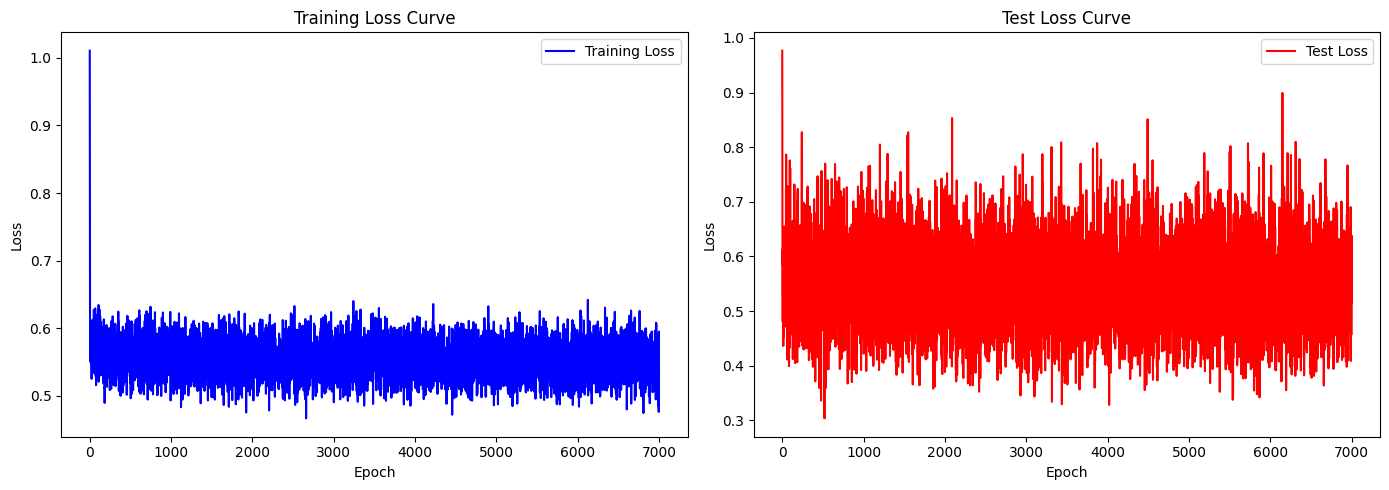

CPU times: user 10min, sys: 1.55 s, total: 10min 2s
Wall time: 10min 15s


In [70]:
%%time
T = 100
alpha_min = 0.95
alpha_max = 0.9998
mlp1 = DenoisingMLP('cpu', T, 'identity', 'zero')
train(mlp1, train_dataloader, test_dataloader, alpha_min=alpha_min, alpha_max=alpha_max, T=T, lr=4e-4, n_epochs=7000)

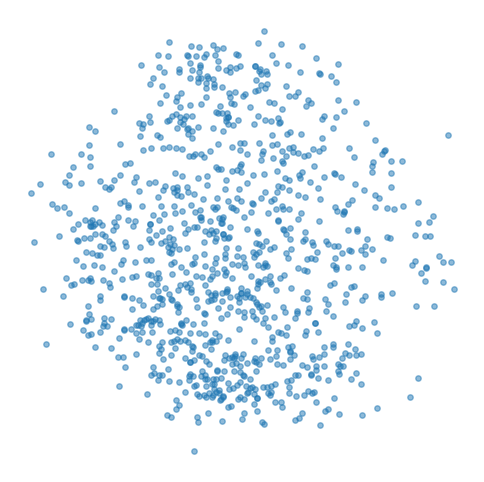

In [76]:

steps = sample(1000, mlp1, alpha_min=alpha_min, alpha_max=alpha_max, T=T)
plt.figure(figsize=[6, 6])
plt.scatter(steps[-1][:,0],steps[-1][:,1],s=15,alpha=0.5)
plt.axis('off')

plt.show()
plt.close()

**Observation:** The drift fields at higher timesteps look very different from those at lower timesteps -- a single time-agnostic network cannot capture both regimes. Let us supply timestep information.

### Attempt 2: Fourier input + Linear time embedding

Fourier features for the input help the network learn high-frequency spatial patterns (see Tancik et al., *Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains*, 2020). A linear time embedding $t/T - 0.5$ gives the network a scalar indication of the noise level.

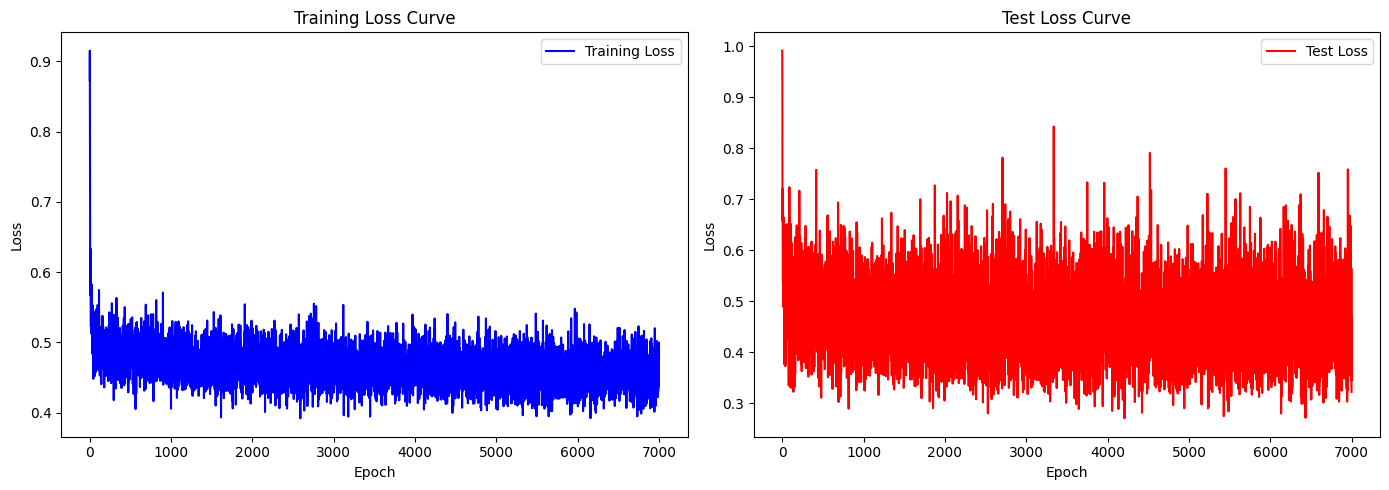

CPU times: user 10min 22s, sys: 1.55 s, total: 10min 23s
Wall time: 10min 32s


In [72]:
%%time
mlp2 = DenoisingMLP('cpu', T, 'fourier', 'linear')
train(mlp2, train_dataloader, test_dataloader, alpha_min=alpha_min, alpha_max=alpha_max, T=T, lr=4e-4, n_epochs=7000)

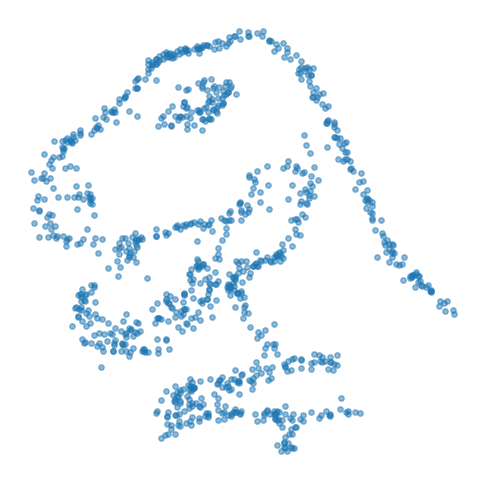

In [73]:
torch.manual_seed(42)
steps = sample(1000, mlp2, alpha_min=alpha_min, alpha_max=alpha_max, T=T)
plt.figure(figsize=[6, 6])
plt.scatter(steps[-1][:,0],steps[-1][:,1],s=15,alpha=0.5)
plt.axis('off')
plt.show()
plt.close()

### Attempt 3: Fourier input + Fourier time embedding

Using Fourier embeddings for *both* position and time gives the richest representation. This is the standard approach in modern diffusion models (sinusoidal positional encodings for time, similar to Transformer architectures).

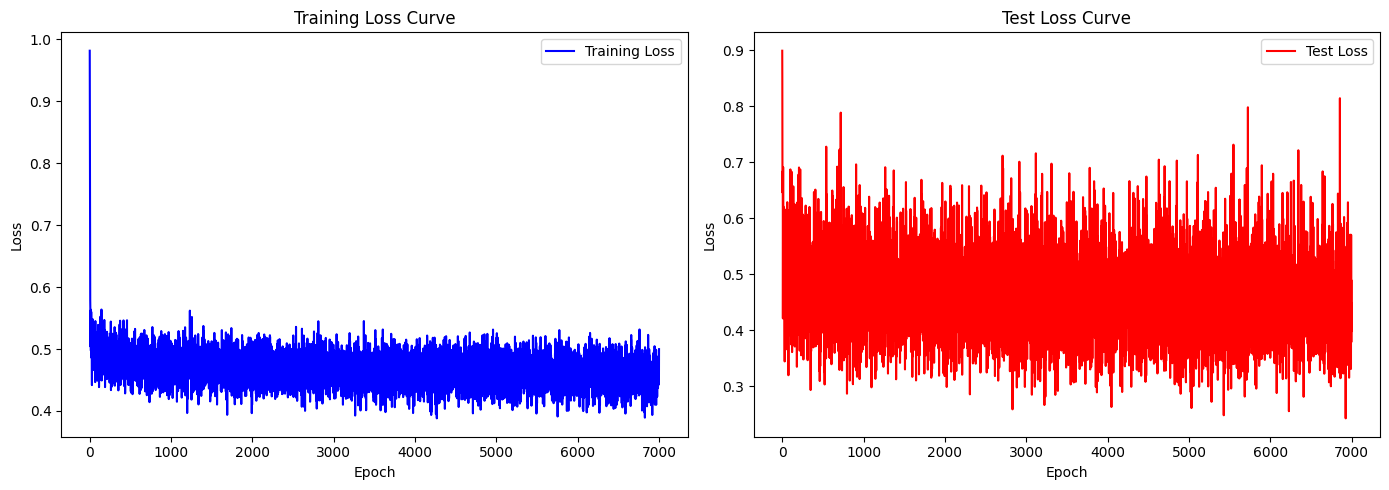

CPU times: user 11min 27s, sys: 1.74 s, total: 11min 29s
Wall time: 11min 39s


In [74]:
%%time
mlp3 = DenoisingMLP('cpu', T, 'fourier', 'fourier')
train(mlp3, train_dataloader, test_dataloader, alpha_min=alpha_min, alpha_max=alpha_max, T=T, lr=4e-4, n_epochs=7000)

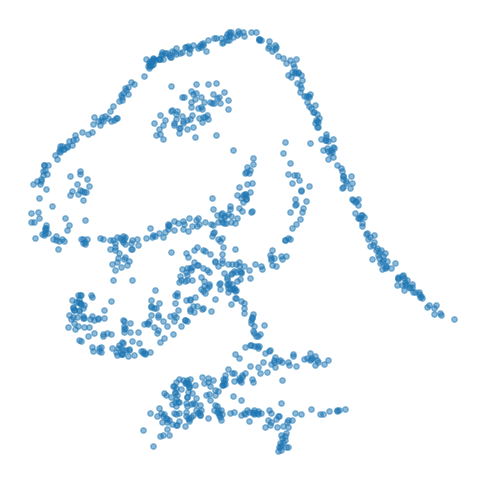

In [75]:
torch.manual_seed(42)
steps = sample(1000, mlp3, alpha_min=alpha_min, alpha_max=alpha_max, T=T)
plt.figure(figsize=[6, 6])
plt.scatter(steps[-1][:,0],steps[-1][:,1],s=15,alpha=0.5)
plt.axis('off')
plt.show()
plt.close()

**Observation:** The samples improve but still have artifacts. Looking at the forward process, everything beyond step 25 already looks like pure noise. The model wastes capacity fitting nearly indistinguishable high-noise regimes.

### Attempt 4: Fourier/Fourier + Adjusted noise schedule

We construct a *slower* noise schedule so that $\bar{\alpha}_t$ stays higher for more timesteps, giving the model more "signal-rich" training targets. Specifically, we raise $\alpha_{\min}$ from $0.95$ to $0.98$, stretching the useful range over all $T$ steps.

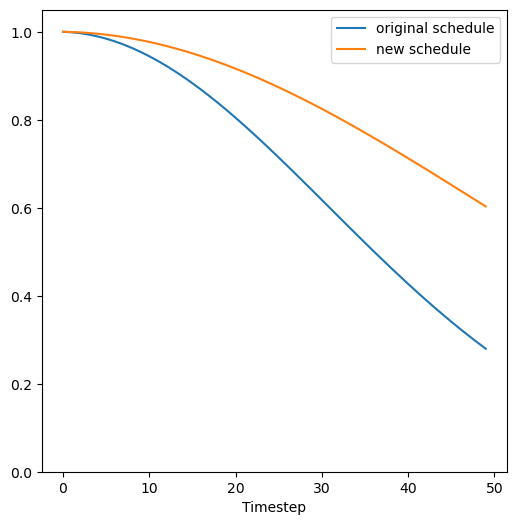

In [ ]:
# Let's construct a noising schedule which takes the alpha_bar that our old schedule had around step 25,
# then stretches the schedule so that we end up with that same value at step 50

old_alpha_min = 0.95
old_alpha_max = 0.9999
T = 50
old_alpha = torch.linspace(old_alpha_max, old_alpha_min, T)
old_alpha_bar = torch.cumprod(old_alpha, dim=-1).reshape(-1,1)

alpha_min = 0.98
alpha_max = 0.9999
new_alpha = torch.linspace(alpha_max, alpha_min, T)
alpha_bar = torch.cumprod(new_alpha, dim=-1).reshape(-1,1)
plt.figure(figsize=[6, 6])
plt.plot(torch.arange(T), old_alpha_bar, label="original schedule")
plt.plot(torch.arange(T), alpha_bar, label="new schedule")
plt.legend()
plt.xlabel('Timestep')
plt.ylim(0,1.05)
plt.show()
plt.close()

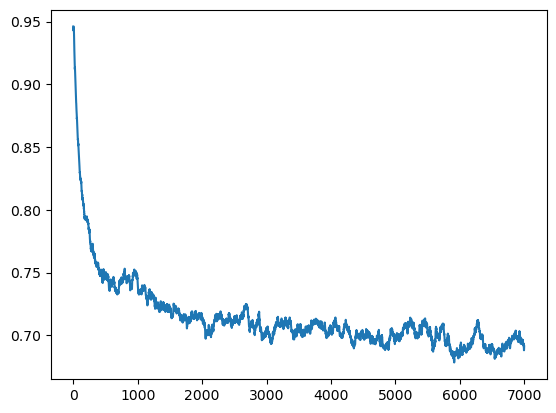

CPU times: user 1min 14s, sys: 3.9 s, total: 1min 18s
Wall time: 1min 18s


In [ ]:
%%time
mlp4 = DenoisingMLP('cpu', T, 'fourier', 'fourier')
train(mlp4, train_dataloader, test_dataloader, alpha_min=alpha_min, alpha_max=alpha_max, T=T, lr=4e-4, n_epochs=7000)

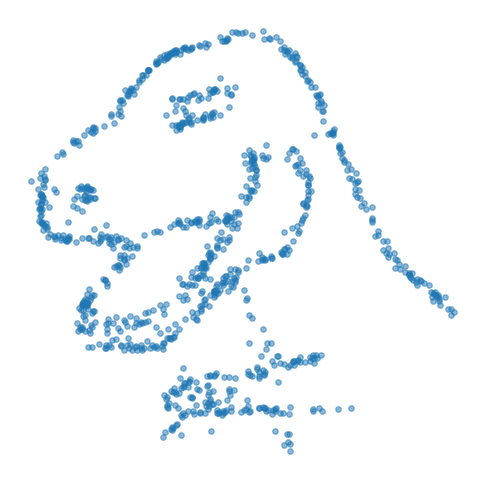

In [ ]:
torch.manual_seed(42)
steps = sample(1000, mlp4, alpha_min=alpha_min, alpha_max=alpha_max, T=T)
plt.figure(figsize=[6, 6])
plt.scatter(steps[-1][:,0],steps[-1][:,1],s=15,alpha=0.5)
plt.axis('off')

plt.show()
plt.close()

# Let's try another dataset

In [ ]:

# Get the moons dataset
moons_ds = get_dataset('moons')
moons_tensor, = moons_ds[:]

# Normalize the moons dataset (zero mean, unit variance)
moons_tensor = (moons_tensor - moons_tensor.mean()) / moons_tensor.std()

# Create a larger set by concatenating copies of the moons data
moons_viz_input = torch.cat(
    (moons_tensor, moons_tensor, moons_tensor, moons_tensor, moons_tensor, moons_tensor),
    dim=0
)

# Generate noisy versions of the moons dataset using the forward process
moons_series = forward_noise_dataset(moons_viz_input, beta_min=(1-0.9999), beta_max=(1-0.95), n_steps=200)

# Plot individual noisy versions of the dataset to visualize the diffusion process
for i in range(len(moons_series)):
    data = moons_series[i]
    plt.figure(figsize=[6, 6])
    plt.scatter(data[:, 0], data[:, 1], s=15, alpha=0.5)
    plt.axis('off')
    plt.close()

# Timesteps to display for visualization
display_ts = [0, 6, 12, 25, 50, 100, 200]

# Use the custom scatter plotting function to visualize multiple timesteps in one plot
scatters(len(display_ts), 1, [moons_series[i] for i in display_ts], ["" for _ in range(len(display_ts))], display_ts)

In [ ]:
%%time
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set the manual seed for reproducibility
torch.manual_seed(431)

# Define the device to be used (e.g., GPU if available)
device = 'cpu'

moons_ds = get_dataset('moons')
moons_tensor, = moons_ds[:]

# Normalize the moons dataset (zero mean, unit variance)
moons_tensor = (moons_tensor - moons_tensor.mean()) / moons_tensor.std()

# Shuffle the indices of the dataset randomly using `torch.randperm`
# This will be used to split the dataset into training and test sets
idxs = torch.randperm(moons_tensor.shape[0]).long()

# Calculate the number of training samples (90% of the total data)
num_train_data = int(idxs.shape[0] * 0.9)

# Split the data into training and test sets using the shuffled indices
# Training data is 90% of the total dataset
train_data = torch.utils.data.TensorDataset(moons_tensor[idxs[:num_train_data]].float().to(device))

# Test data is the remaining 10% of the dataset
test_data = torch.utils.data.TensorDataset(moons_tensor[idxs[num_train_data:]].float().to(device))

# Define the batch size for the DataLoader
bs = 32

# Create DataLoader for training data with the specified batch size
# `shuffle=True` ensures that the data is shuffled at each epoch
train_dataloader = DataLoader(train_data, bs, shuffle=True)

# Create DataLoader for test data with the specified batch size
# `shuffle=True` ensures that the data is shuffled at each iteration
test_dataloader = DataLoader(test_data, bs, shuffle=True)

# Define model and training parameters
T = 200
alpha_min = 0.94
alpha_max = 0.999

# Create an instance of the DenoisingMLP model
mlp4 = DenoisingMLP(device, T, input_embedding='fourier', time_embedding='fourier')

# Train the model on the moons dataset
train(mlp4, train_dataloader, test_dataloader, alpha_min=alpha_min, alpha_max=alpha_max, T=T, lr=4e-4, n_epochs=7000)

# Set the manual seed for reproducibility
torch.manual_seed(42)

# Generate samples from the trained model using the reverse process
steps = sample(1000, mlp4, alpha_min=alpha_min, alpha_max=alpha_max, T=T)

# Visualize the generated samples after training
plt.figure(figsize=[6, 6])
plt.scatter(steps[-1][:, 0], steps[-1][:, 1], s=15, alpha=0.5)
plt.axis('off')
plt.title("Generated Samples from Moons Dataset (After Reverse Process)")
plt.show()
plt.close()

## Summary

**Key takeaways from this notebook:**

1. **Diffusion = noise then denoise.** The forward process $q(x_t \mid x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}\,x_{t-1}, \beta_t I)$ gradually corrupts data into Gaussian noise. The reverse process uses a learned denoiser $\epsilon_\theta(x_t, t)$ to recover structure.

2. **The training loss is simple.** The noise-prediction objective $\mathcal{L} = \mathbb{E}\|\epsilon - \epsilon_\theta(x_t, t)\|^2$ is just an MSE regression. No adversarial training or complex likelihood computation is needed.

3. **Embeddings matter.** Fourier features for both position and time dramatically improve sample quality by helping the MLP represent high-frequency spatial patterns and distinguish different noise levels.

4. **The noise schedule is a key hyperparameter.** A schedule that decays $\bar{\alpha}_t$ too quickly wastes model capacity on indistinguishable high-noise regimes. Tuning the schedule so the model spends more time in signal-rich regions improves generation quality.

5. **Scaling up.** The same principles apply to large-scale image diffusion models (e.g., Stable Diffusion), but with U-Net architectures, latent-space diffusion, and text conditioning replacing the simple MLP used here.